In [36]:
from keras.layers import Input, Dense
from keras.models import Model, Sequential
from keras import regularizers
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.manifold import TSNE
from sklearn import preprocessing 
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import seaborn as sns

In [37]:
from keras.models import Model, load_model
from keras.layers import Input,Dense, BatchNormalization #layers of autoencoder
from keras.callbacks import ModelCheckpoint, TensorBoard, EarlyStopping #callbacks
from keras import regularizers #regularization
import keras
import sklearn.metrics as metrics #metrics librry

In [38]:
from tensorflow.python.client import device_lib
device_lib.list_local_devices()

[name: "/device:CPU:0"
 device_type: "CPU"
 memory_limit: 268435456
 locality {
 }
 incarnation: 6624216256051027002
 xla_global_id: -1]

In [39]:
def printandwrite(loc, text, firstLine = False):       
    print(text)
    if firstLine:
        sourceFile = open(loc, 'w')
    else:
        sourceFile = open(loc, 'a')
    sourceFile.write(text)
    sourceFile.close()

# Load Dataset

In [40]:
load_Folder = "./Datasets/WGN/"

## Real normal

In [41]:
alpha_SNR_25 = np.load("../../Datasets/Numpy/WGN/alpha_SNR_25_MP.npy", allow_pickle=True)
alpha_SNR_20 = np.load("../../Datasets/Numpy/WGN/alpha_SNR_20_MP.npy", allow_pickle=True)
alpha_SNR_15 = np.load("../../Datasets/Numpy/WGN/alpha_SNR_15_MP.npy", allow_pickle=True)

## Real Anomalous

In [46]:
alpha_sub_SNR_25 = np.load("../../Datasets/Numpy/WGN/alpha_sub_SNR_25_MP.npy", allow_pickle=True)
alpha_sub_SNR_20 = np.load("../../Datasets/Numpy/WGN/alpha_sub_SNR_20_MP.npy", allow_pickle=True)
alpha_sub_SNR_15 = np.load("../../Datasets/Numpy/WGN/alpha_sub_SNR_15_MP.npy", allow_pickle=True)

# To compare the similarity using euclidean distance, we need the signal data to be the same lenght. As such, we will remove access information at the end as we assume we have knowledge of the length of time the benign program will take.

In [51]:
def cutToLength(dataset, length):
    new_Dataset = np.zeros((dataset.shape[0],length))
    
    for i in range(dataset.shape[0]):
        temp = dataset[i]
        new_Dataset[i] = temp[:length]
    
    new_Dataset = np.array(new_Dataset)
    return new_Dataset

# alpha

In [52]:
print(alpha_SNR_25.shape)

(3000, 12)


In [53]:
print(alpha_sub_SNR_25.shape)
print(alpha_sub_SNR_20.shape)
print(alpha_sub_SNR_15.shape)

(1312, 13)
(1312, 13)
(1312, 13)
(1312, 13)
(1312, 13)


In [54]:
alpha_sub_SNR_25 = cutToLength(alpha_sub_SNR_25, 12)
alpha_sub_SNR_20 = cutToLength(alpha_sub_SNR_20, 12)
alpha_sub_SNR_15 = cutToLength(alpha_sub_SNR_15, 12)
print(alpha_SNR_20.shape)
print(alpha_sub_SNR_20.shape)

(3000, 12)
(1312, 12)


# Method to do anomaly detection

In [67]:
import sys
# setting path
sys.path.append('../../')
from Modules.Tests import KNN_Exp

# alpha

# Settings

In [68]:
program_N = alpha_SNR_25
program_A = alpha_sub_SNR_25
SNR = "25"

folder = "./Results/kNN/Alpha_SNR_" + SNR + "/"

NormalTest = program_N[2000:3000]
AnomalyTest = program_A[0:1000]

Beginning Tests...


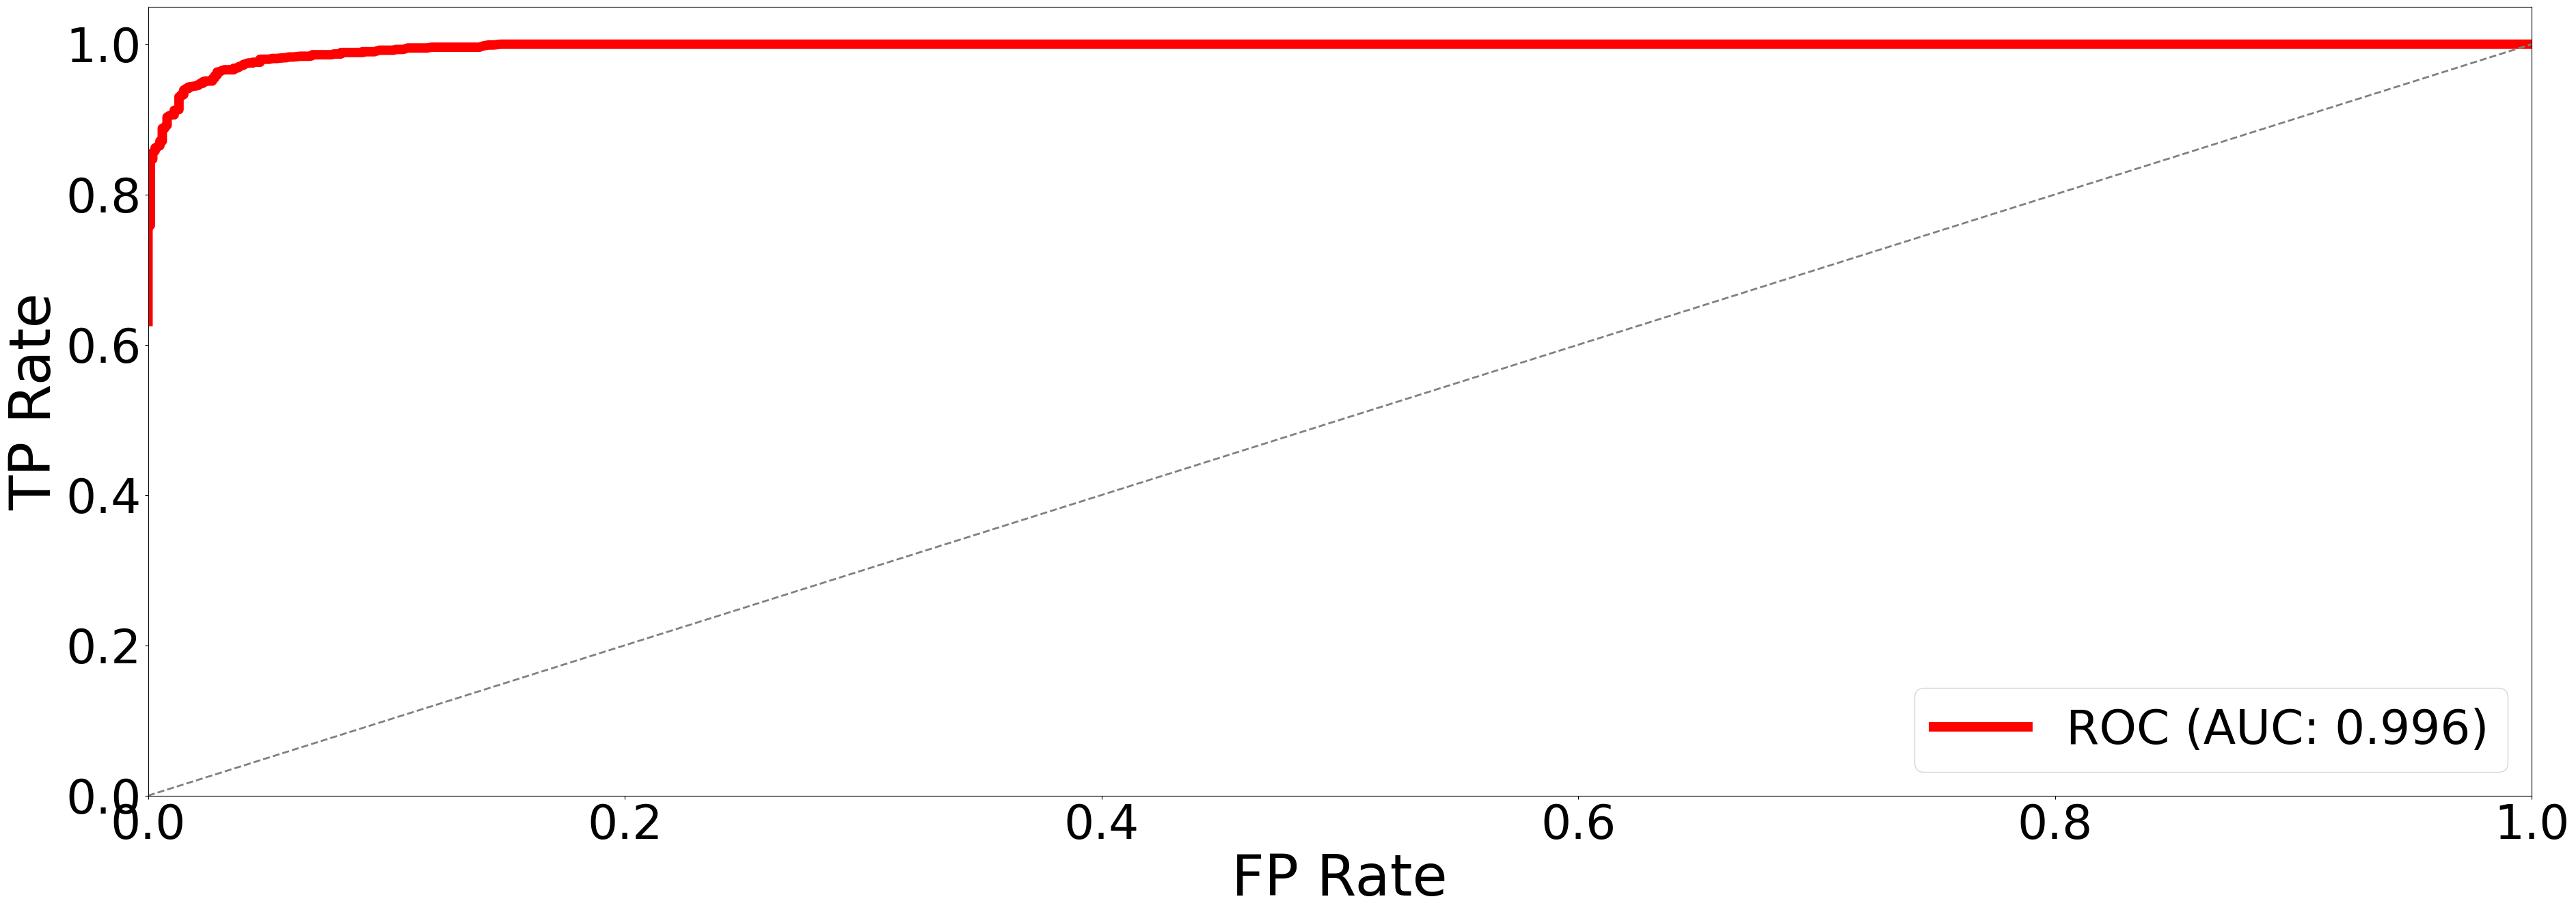

Method: KNN
Normal Dataset Used: alpha SNR-25 TS-2000
Size of Training Set: 2000
Test Set Used: alpha SNR-25 normal along with alpha_sub SNR-25 anomaly instances
Size of Test Set: 1000 (normal) 1000 (anomalous) 
Neighbors: 10
Avg f1 score: 0.9669669669669669
Max f1 score: 0.9669669669669669
Min f1 score: 0.9669669669669669
Avg acc score: 0.967
Max acc score: 0.967
Min acc score: 0.967
Avg AUC score: 0.9960180000000001
Max AUC score: 0.9960180000000001
Min AUC score: 0.9960180000000001
Avg Precision score: 0.9707661290322581
Max Precision score: 0.9707661290322581
Min Precision score: 0.9707661290322581
Avg Recall score: 0.966
Max Recall score: 0.966
Min Recall score: 0.966
Time: 16.768007799983025


In [69]:
Training_Amount = 2000

NormalTrain = program_N[0:Training_Amount]
NormalTest = program_N[2000:3000]
AnomalyTest = program_A[0:1000]

normalTrainInst = "alpha SNR-" + SNR + " TS-" + str(Training_Amount)
normalTestInst = "alpha SNR-" +SNR
anomalyInst = "alpha_sub SNR-" +SNR

name = normalTrainInst + " vs " + anomalyInst

path = folder + name + "/"

kFold = 1

neighbor = np.array([10])

f1Best, accBest, aucBest, precBest, recallBest = KNN_Exp.runExperiment(NormalTrain, NormalTest, AnomalyTest, normalTrainInst, 
                                                    normalTestInst, anomalyInst, name, path, neighbors = neighbor, numFold = kFold)

Beginning Tests...


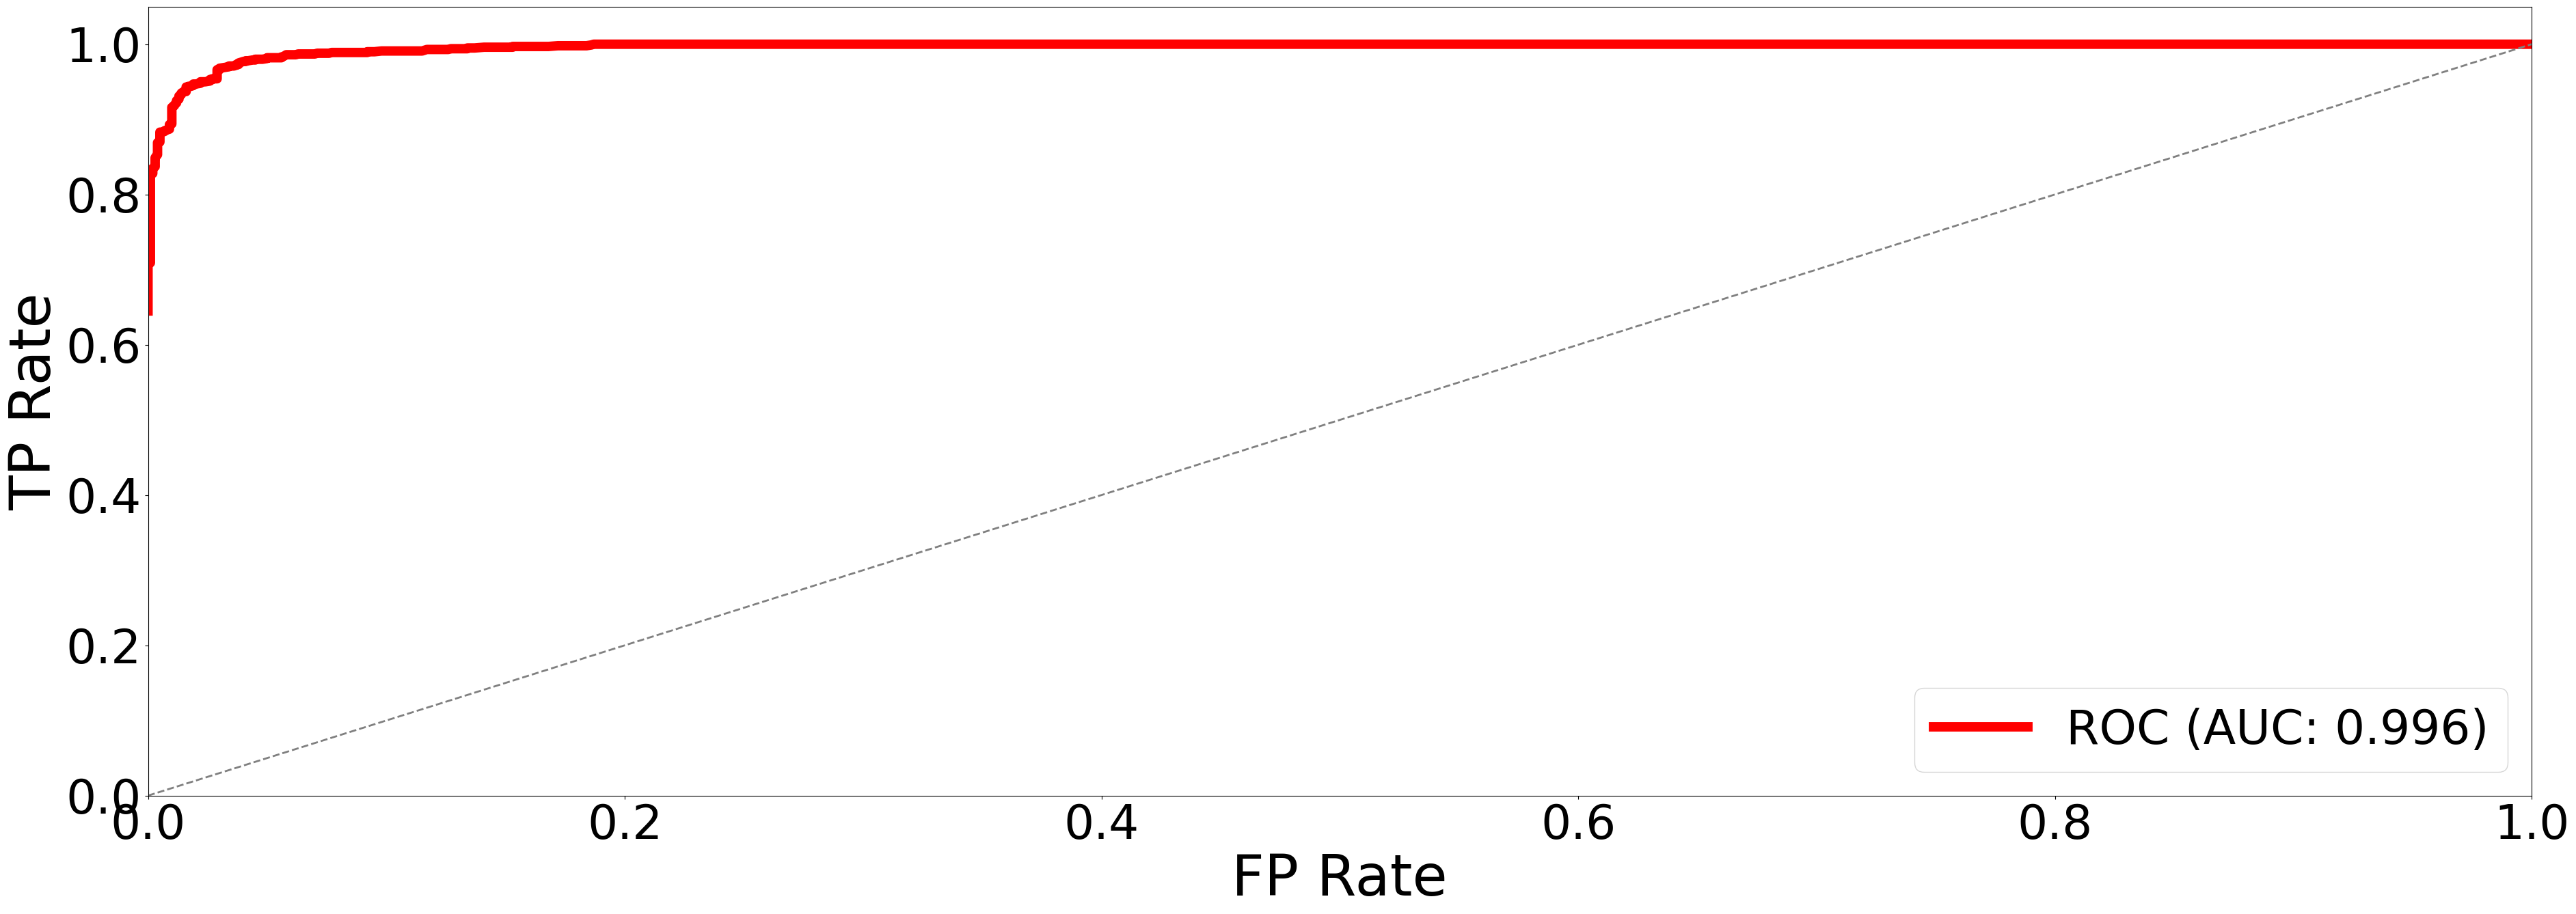

Method: KNN
Normal Dataset Used: alpha SNR-25 TS-1500
Size of Training Set: 1500
Test Set Used: alpha SNR-25 normal along with alpha_sub SNR-25 anomaly instances
Size of Test Set: 1000 (normal) 1000 (anomalous) 
Neighbors: 10
Avg f1 score: 0.968968968968969
Max f1 score: 0.968968968968969
Min f1 score: 0.968968968968969
Avg acc score: 0.969
Max acc score: 0.969
Min acc score: 0.969
Avg AUC score: 0.9958485
Max AUC score: 0.9958485
Min AUC score: 0.9958485
Avg Precision score: 0.969939879759519
Max Precision score: 0.969939879759519
Min Precision score: 0.969939879759519
Avg Recall score: 0.968
Max Recall score: 0.968
Min Recall score: 0.968
Time: 15.063424900057726


In [70]:
Training_Amount = 1500

NormalTrain = program_N[0:Training_Amount]
NormalTest = program_N[2000:3000]
AnomalyTest = program_A[0:1000]

normalTrainInst = "alpha SNR-" + SNR + " TS-" + str(Training_Amount)
normalTestInst = "alpha SNR-" +SNR
anomalyInst = "alpha_sub SNR-" +SNR

name = normalTrainInst + " vs " + anomalyInst

path = folder + name + "/"

kFold = 1

neighbor = np.array([10])

f1Best, accBest, aucBest, precBest, recallBest = KNN_Exp.runExperiment(NormalTrain, NormalTest, AnomalyTest, normalTrainInst, 
                                                    normalTestInst, anomalyInst, name, path, neighbors = neighbor, numFold = kFold)

Beginning Tests...


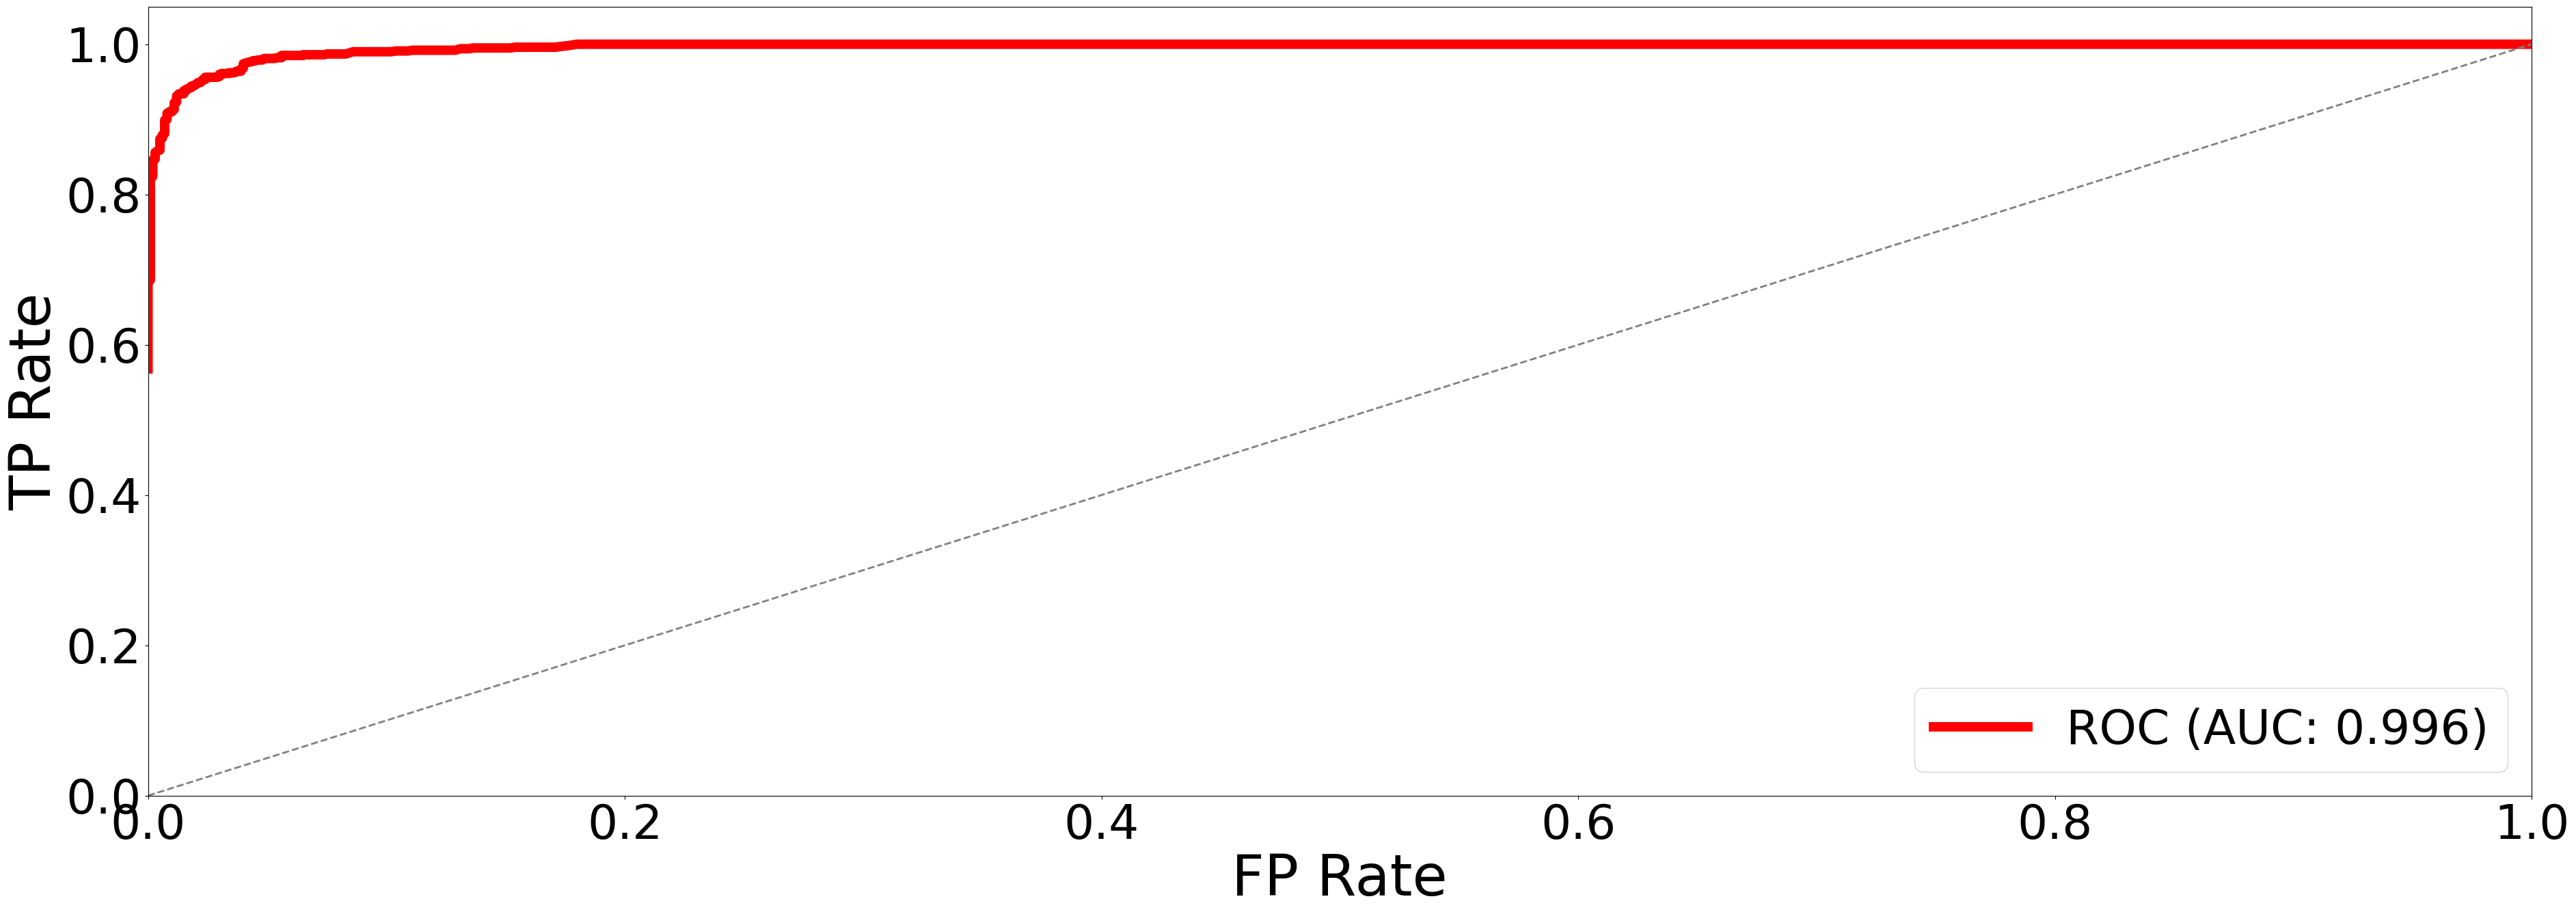

Method: KNN
Normal Dataset Used: alpha SNR-25 TS-1000
Size of Training Set: 1000
Test Set Used: alpha SNR-25 normal along with alpha_sub SNR-25 anomaly instances
Size of Test Set: 1000 (normal) 1000 (anomalous) 
Neighbors: 10
Avg f1 score: 0.9673590504451038
Max f1 score: 0.9673590504451038
Min f1 score: 0.9673590504451038
Avg acc score: 0.967
Max acc score: 0.967
Min acc score: 0.967
Avg AUC score: 0.9957
Max AUC score: 0.9957
Min AUC score: 0.9957
Avg Precision score: 0.960552268244576
Max Precision score: 0.960552268244576
Min Precision score: 0.960552268244576
Avg Recall score: 0.978
Max Recall score: 0.978
Min Recall score: 0.978
Time: 16.855274600093253


In [71]:
Training_Amount = 1000

NormalTrain = program_N[0:Training_Amount]
NormalTest = program_N[2000:3000]
AnomalyTest = program_A[0:1000]

normalTrainInst = "alpha SNR-" + SNR + " TS-" + str(Training_Amount)
normalTestInst = "alpha SNR-" +SNR
anomalyInst = "alpha_sub SNR-" +SNR

name = normalTrainInst + " vs " + anomalyInst

path = folder + name + "/"

kFold = 1

neighbor = np.array([10])

f1Best, accBest, aucBest, precBest, recallBest = KNN_Exp.runExperiment(NormalTrain, NormalTest, AnomalyTest, normalTrainInst, 
                                                    normalTestInst, anomalyInst, name, path, neighbors = neighbor, numFold = kFold)

Beginning Tests...


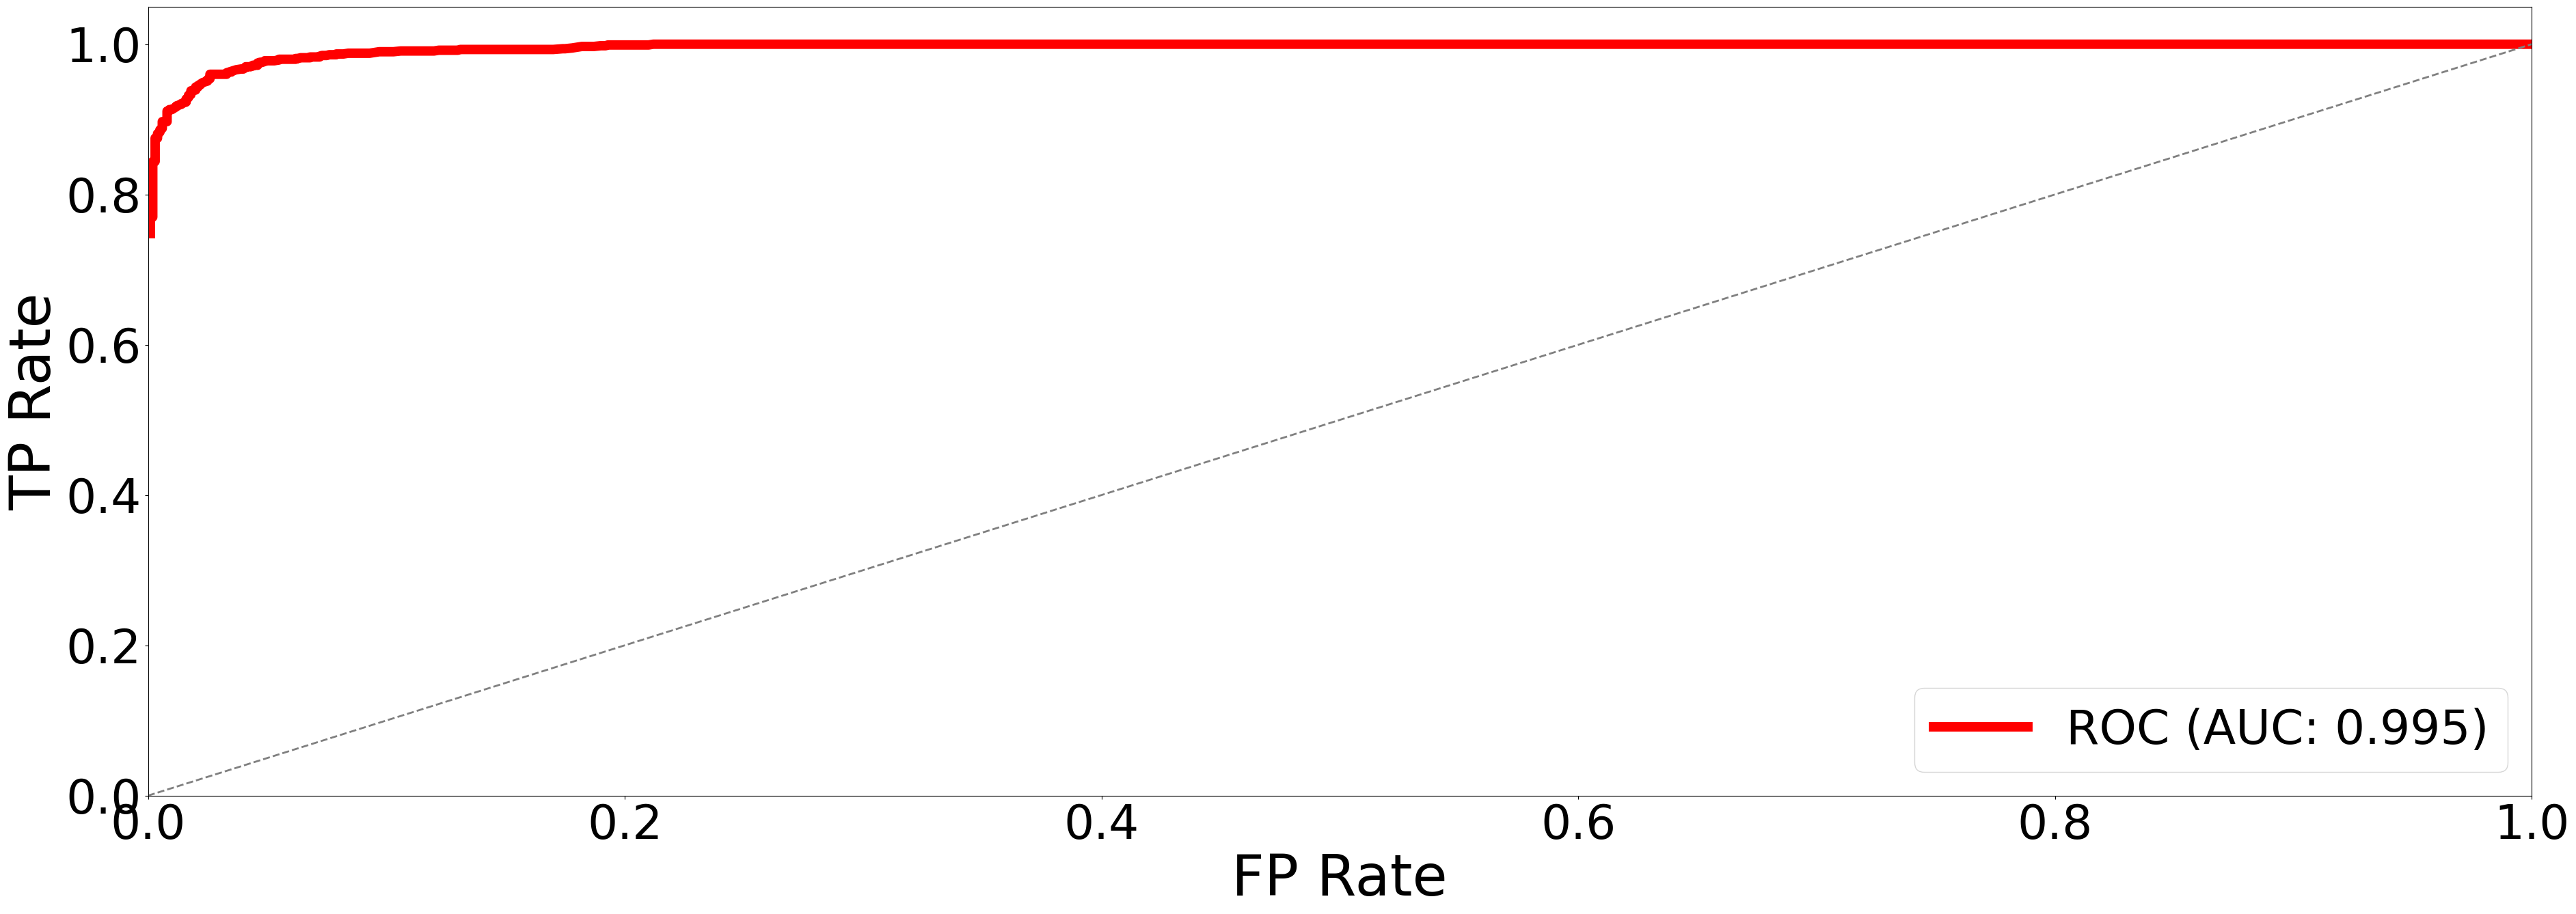

Method: KNN
Normal Dataset Used: alpha SNR-25 TS-500
Size of Training Set: 500
Test Set Used: alpha SNR-25 normal along with alpha_sub SNR-25 anomaly instances
Size of Test Set: 1000 (normal) 1000 (anomalous) 
Neighbors: 10
Avg f1 score: 0.9667673716012085
Max f1 score: 0.9667673716012085
Min f1 score: 0.9667673716012085
Avg acc score: 0.967
Max acc score: 0.967
Min acc score: 0.967
Avg AUC score: 0.994587
Max AUC score: 0.994587
Min AUC score: 0.994587
Avg Precision score: 0.973630831643002
Max Precision score: 0.973630831643002
Min Precision score: 0.973630831643002
Avg Recall score: 0.96
Max Recall score: 0.96
Min Recall score: 0.96
Time: 16.78832729998976


In [72]:
Training_Amount = 500

NormalTrain = program_N[0:Training_Amount]
NormalTest = program_N[2000:3000]
AnomalyTest = program_A[0:1000]

normalTrainInst = "alpha SNR-" + SNR + " TS-" + str(Training_Amount)
normalTestInst = "alpha SNR-" +SNR
anomalyInst = "alpha_sub SNR-" +SNR

name = normalTrainInst + " vs " + anomalyInst

path = folder + name + "/"

kFold = 1

neighbor = np.array([10])

f1Best, accBest, aucBest, precBest, recallBest = KNN_Exp.runExperiment(NormalTrain, NormalTest, AnomalyTest, normalTrainInst, 
                                                    normalTestInst, anomalyInst, name, path, neighbors = neighbor, numFold = kFold)

Beginning Tests...


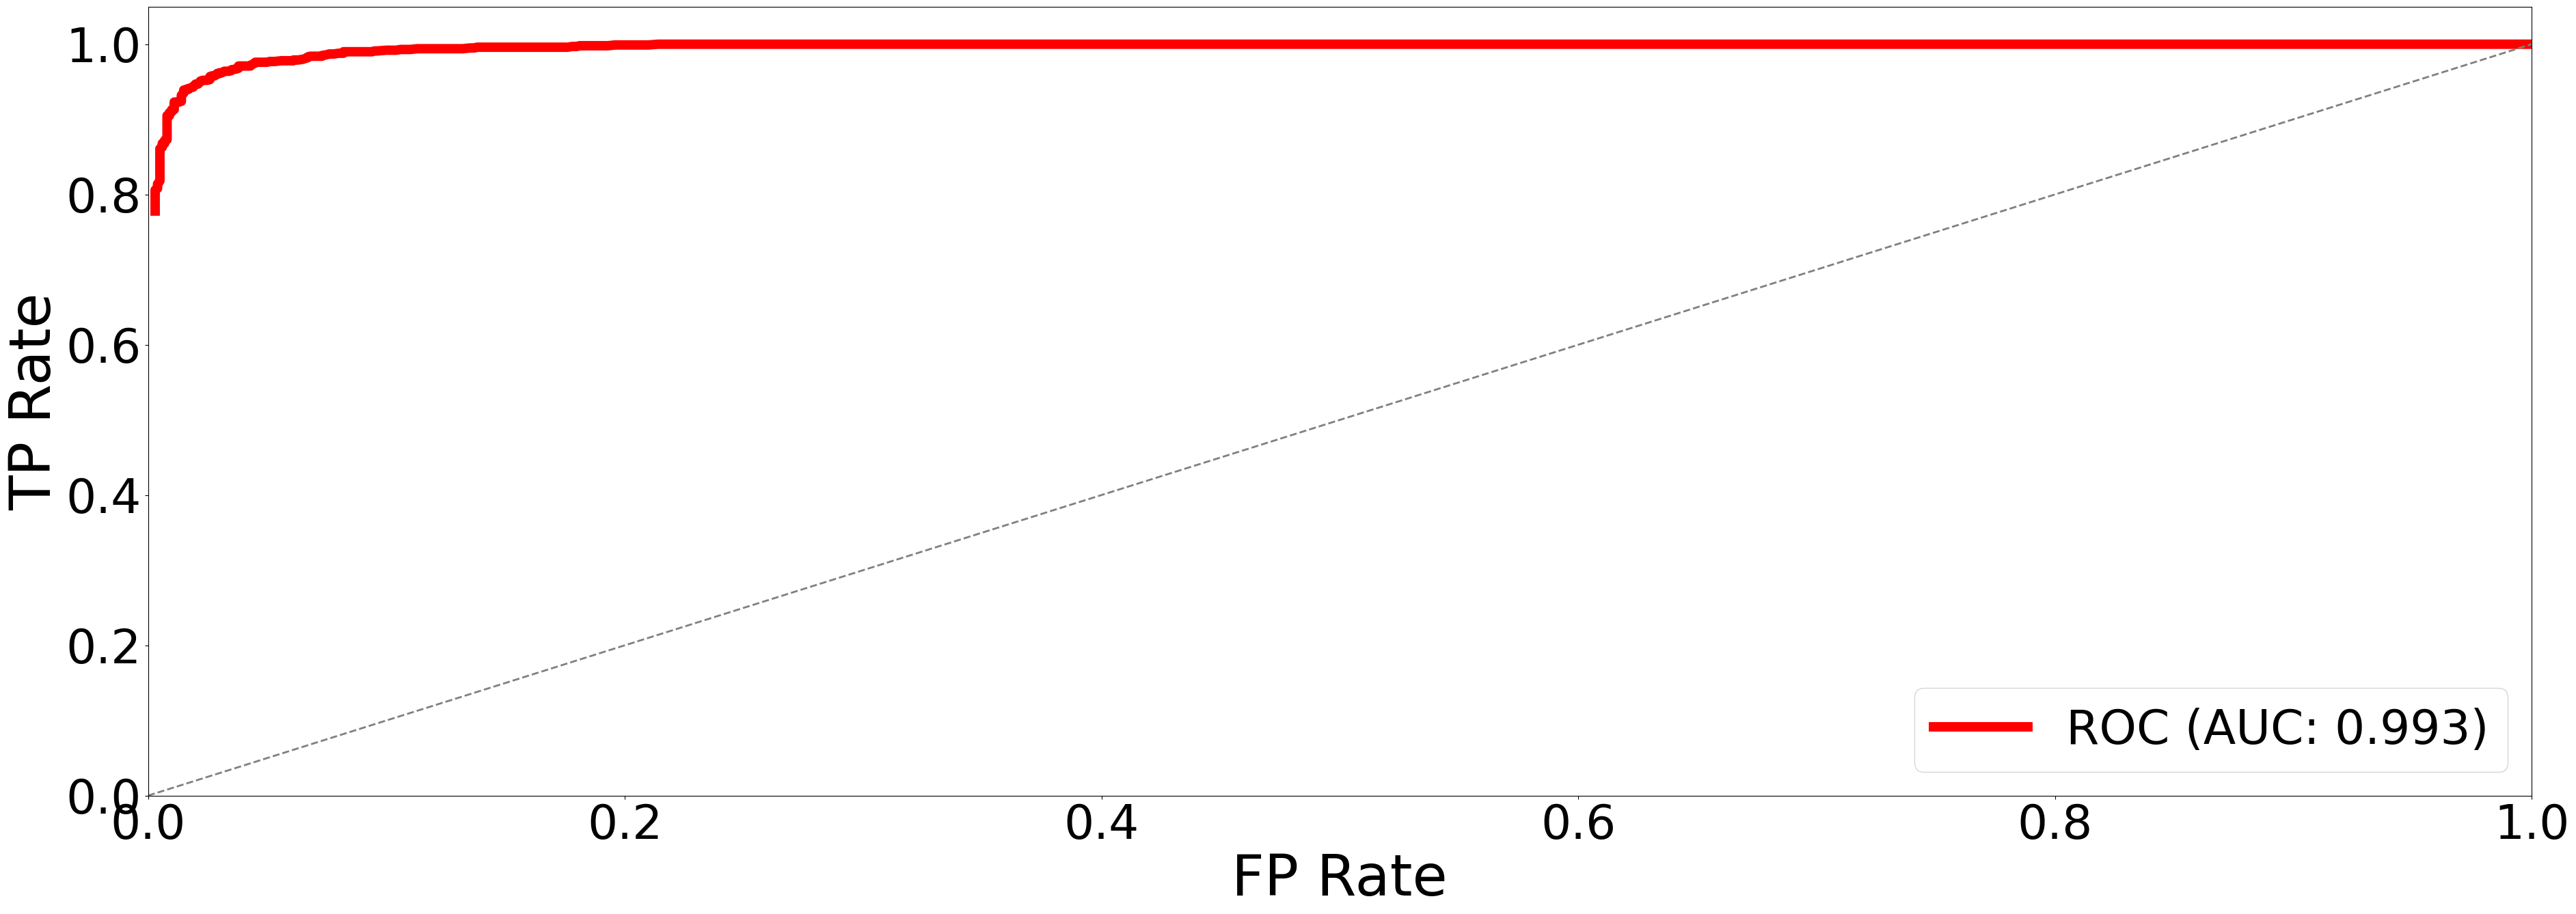

Method: KNN
Normal Dataset Used: alpha SNR-25 TS-100
Size of Training Set: 100
Test Set Used: alpha SNR-25 normal along with alpha_sub SNR-25 anomaly instances
Size of Test Set: 1000 (normal) 1000 (anomalous) 
Neighbors: 10
Avg f1 score: 0.966650074664012
Max f1 score: 0.966650074664012
Min f1 score: 0.966650074664012
Avg acc score: 0.9665
Max acc score: 0.9665
Min acc score: 0.9665
Avg AUC score: 0.9930975
Max AUC score: 0.9930975
Min AUC score: 0.9930975
Avg Precision score: 0.9623389494549058
Max Precision score: 0.9623389494549058
Min Precision score: 0.9623389494549058
Avg Recall score: 0.971
Max Recall score: 0.971
Min Recall score: 0.971
Time: 17.019986799918115


In [73]:
Training_Amount = 100

NormalTrain = program_N[0:Training_Amount]
NormalTest = program_N[2000:3000]
AnomalyTest = program_A[0:1000]

normalTrainInst = "alpha SNR-" + SNR + " TS-" + str(Training_Amount)
normalTestInst = "alpha SNR-" +SNR
anomalyInst = "alpha_sub SNR-" +SNR

name = normalTrainInst + " vs " + anomalyInst

path = folder + name + "/"

kFold = 1

neighbor = np.array([10])

f1Best, accBest, aucBest, precBest, recallBest = KNN_Exp.runExperiment(NormalTrain, NormalTest, AnomalyTest, normalTrainInst, 
                                                    normalTestInst, anomalyInst, name, path, neighbors = neighbor, numFold = kFold)